In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

seg_model = YOLO("yolov8x-seg.pt")  # <-- segmentation model (not yolov8l.pt)


image 1/1 /home/administrator/repos/yolo-testing/images/snapshot.jpg: 384x640 5 cars, 1 truck, 2 potted plants, 705.5ms
Speed: 2.2ms preprocess, 705.5ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 640)


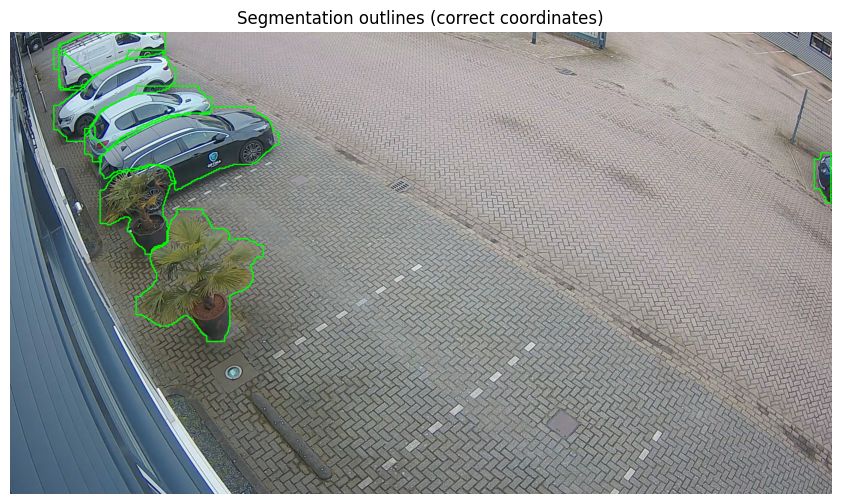

In [ ]:

image_path = Path("images/snapshot.jpg")
img = cv2.imread(str(image_path))

results = seg_model(str(image_path), conf=0.3)
r = results[0]

outline_img = img.copy()

if r.masks is None:
    print("No masks detected.")
else:
    # r.masks.xy is a list of polygons (each polygon is an Nx2 array of x,y points)
    for poly in r.masks.xy:
        pts = np.array(poly, dtype=np.int32)          # shape (N, 2)
        pts = pts.reshape((-1, 1, 2))                 # OpenCV expects (N, 1, 2)
        cv2.polylines(outline_img, [pts], True, (0, 255, 0), 2)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(outline_img, cv2.COLOR_BGR2RGB))
plt.title("Segmentation outlines (correct coordinates)")
plt.axis("off")
plt.show()